Part A. Setup and data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import keras
from keras import layers


In [2]:
X, y = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    return_X_y=True
)

y = y.astype(int)

print("Images:", X.shape)
print("Labels:", y.shape, "| classes:", np.unique(y))


Images: (70000, 784)
Labels: (70000,) | classes: [0 1 2 3 4 5 6 7 8 9]


In [3]:
X = X.reshape(-1, 28, 28, 1).astype("float32") / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training images:", X_train.shape)
print("Test images: ", X_test.shape)


Training images: (56000, 28, 28, 1)
Test images:  (14000, 28, 28, 1)


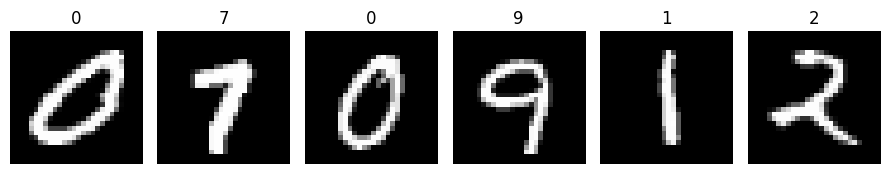

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(9, 2))

for ax, image, label in zip(axes, X_train, y_train):
    ax.imshow(image.reshape(28, 28), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")

plt.tight_layout()
plt.show()


Part B. Build and train your network

In [5]:
keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [8]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True)


In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping]
)


Epoch 1/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - accuracy: 0.9092 - loss: 0.3206 - val_accuracy: 0.9636 - val_loss: 0.1290
Epoch 2/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.9681 - loss: 0.1091 - val_accuracy: 0.9727 - val_loss: 0.0860
Epoch 3/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 43s 66ms/step - accuracy: 0.9763 - loss: 0.0792 - val_accuracy: 0.9796 - val_loss: 0.0679
Epoch 4/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.9811 - loss: 0.0626 - val_accuracy: 0.9807 - val_loss: 0.0614
Epoch 5/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.9835 - loss: 0.0538 - val_accuracy: 0.9823 - val_loss: 0.0556
Epoch 6/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.9851 - loss: 0.0452 - val_accuracy: 0.9834 - val_loss: 0.0524
Epoch 7/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.9876 - loss: 0.0388 - val_accuracy: 0.9868 - val_loss: 0.0495
Epoch 8/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.9886 - loss: 0.0351 - 

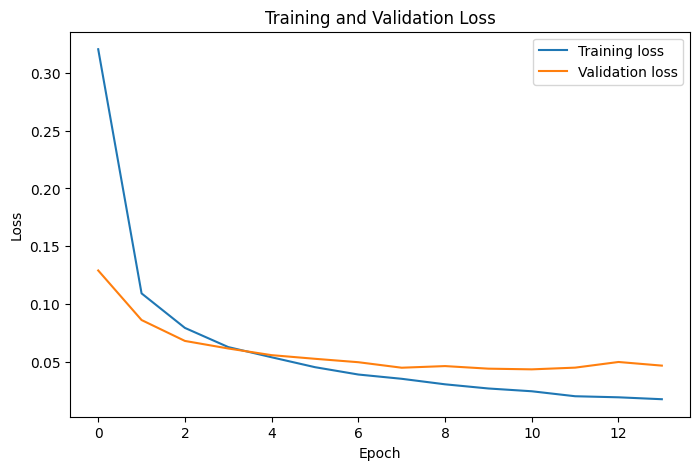

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


Part C. Read the mistakes

In [11]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test accuracy: {test_accuracy:.4f}")

y_pred = model.predict(
    X_test,
    verbose=0
).argmax(axis=1)


Test accuracy: 0.9864


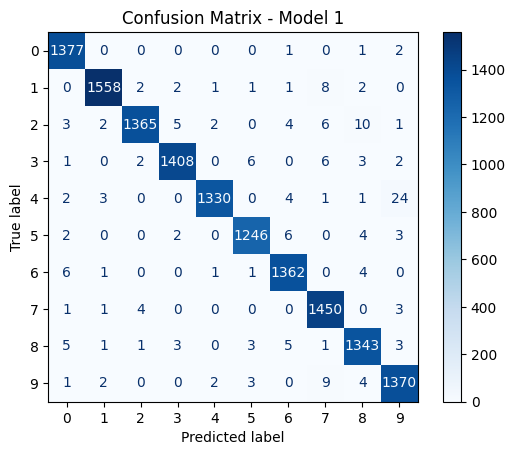

In [12]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Model 1")
plt.show()


In [13]:
cm_without_diagonal = cm.copy()
np.fill_diagonal(cm_without_diagonal, 0)

flat_indices = np.argsort(cm_without_diagonal.ravel())[::-1]

for index in flat_indices[:5]:
    true_digit, predicted_digit = np.unravel_index(index, cm.shape)
    count = cm[true_digit, predicted_digit]
    print(
        f"True digit {true_digit} predicted as {predicted_digit}: {count} times"
    )


True digit 4 predicted as 9: 24 times
True digit 2 predicted as 8: 10 times
True digit 9 predicted as 7: 9 times
True digit 1 predicted as 7: 8 times
True digit 3 predicted as 5: 6 times


The two most common confusion pairs were 4 being predicted as 9, which happened 24 times, and 2 being predicted as 8, which happened 10 times. These mistakes may occur because some handwritten 4s can have shapes that resemble 9s, while handwritten 2s can sometimes have rounded or closed features that make them look similar to 8s. The model may therefore struggle with unusual or ambiguous handwriting styles.

Part D. One change

My prediction is that adding a second convolutional and pooling block will slightly improve the test accuracy because the deeper network can learn more detailed visual features. I also expect that this change may reduce some of the confusion between 4 and 9 and between 2 and 8, although the improvement may be small.

In [14]:
keras.utils.set_random_seed(42)

model2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping2]
)


Epoch 1/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.9163 - loss: 0.2832 - val_accuracy: 0.9773 - val_loss: 0.0787
Epoch 2/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - accuracy: 0.9759 - loss: 0.0785 - val_accuracy: 0.9805 - val_loss: 0.0600
Epoch 3/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.9826 - loss: 0.0554 - val_accuracy: 0.9841 - val_loss: 0.0478
Epoch 4/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.9864 - loss: 0.0446 - val_accuracy: 0.9875 - val_loss: 0.0399
Epoch 5/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.9878 - loss: 0.0377 - val_accuracy: 0.9879 - val_loss: 0.0420
Epoch 6/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.9894 - loss: 0.0330 - val_accuracy: 0.9882 - val_loss: 0.0374
Epoch 7/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.9910 - loss: 0.0288 - val_accuracy: 0.9880 - val_loss: 0.0388
Epoch 8/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - accuracy: 0.9916 - loss: 0.

In [16]:
test_loss2, test_accuracy2 = model2.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Original model test accuracy: {test_accuracy:.4f}")
print(f"Deeper model test accuracy:   {test_accuracy2:.4f}")

y_pred2 = model2.predict(
    X_test,
    verbose=0
).argmax(axis=1)


Original model test accuracy: 0.9864
Deeper model test accuracy:   0.9892


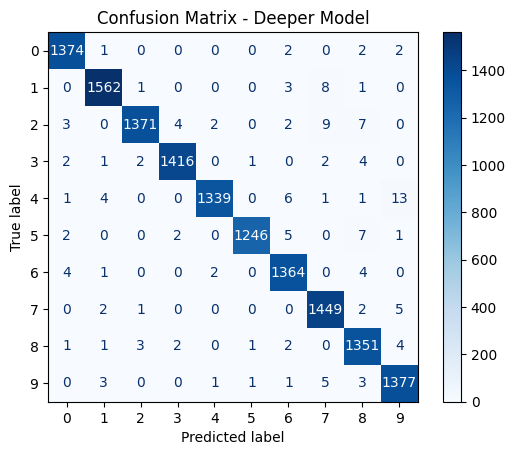

In [17]:
cm2 = confusion_matrix(y_test, y_pred2)

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=np.arange(10)
)

disp2.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Deeper Model")
plt.show()


In [18]:
cm2_without_diagonal = cm2.copy()
np.fill_diagonal(cm2_without_diagonal, 0)

flat_indices2 = np.argsort(cm2_without_diagonal.ravel())[::-1]

for index in flat_indices2[:5]:
    true_digit, predicted_digit = np.unravel_index(index, cm2.shape)
    count = cm2[true_digit, predicted_digit]
    print(
        f"True digit {true_digit} predicted as {predicted_digit}: {count} times"
    )


True digit 4 predicted as 9: 13 times
True digit 2 predicted as 7: 9 times
True digit 1 predicted as 7: 8 times
True digit 5 predicted as 8: 7 times
True digit 2 predicted as 8: 7 times


In [19]:
print(f"Original model test accuracy: {test_accuracy:.4f}")
print(f"Deeper model test accuracy:   {test_accuracy2:.4f}")


Original model test accuracy: 0.9864
Deeper model test accuracy:   0.9892


Ethical considerations

A handwritten digit recognition system may not perform equally well for everyone because handwriting styles can vary across age, country, education, and personal habits. If some handwriting styles are under-represented in the training data, the model may make more mistakes on those styles. A confident but incorrect prediction could have serious consequences in real-world applications such as reading account numbers, postcodes, or other important information. Therefore, the model should be carefully tested on diverse handwriting before being used in a real reading pipeline.

Wrapping up

The first CNN made most of its mistakes when a true 4 was predicted as 9, with 24 errors, followed by a true 2 being predicted as 8, with 10 errors. After adding a second convolutional and pooling block, the test accuracy increased from 98.64% to 98.92%. The number of 4 → 9 errors decreased from 24 to 13, while the 2 → 8 errors decreased from 10 to 7. Therefore, my prediction was correct: the deeper network improved the test accuracy and reduced both of the main confusion pairs. The improvement in accuracy was relatively small, but the reduction in the 4 → 9 confusion was noticeable, suggesting that the additional convolutional layer helped the model learn more detailed features. Overall, the deeper CNN moved the mistakes in a positive direction, although the results should be interpreted using both accuracy and the specific types of errors rather than accuracy alone.